In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import sys, os
from sklearn.decomposition import PCA
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
In this chapter, we look into the encoding of auxiliary variable $u$ as well as iVAE model performance on MNIST (a larger but still toy dataset).

# Setup
### MLP network

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, mu_flag=True, var_flag=True, **kwargs):
        super().__init__()
        self.mu_flag = mu_flag    # mu may be learned or fixed to a constant
        self.var_flag = var_flag  # logvar may be learned or fixed to a constant
        hidden = 50

        slope = 1e-2
        nn_activation = nn.LeakyReLU(slope)

        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn_activation,
            nn.Linear(hidden, hidden),
            nn_activation
        )
        
        if self.mu_flag:
            self.mu = nn.Linear(hidden, out_dim)
        if self.var_flag:
            self.logvar = nn.Linear(hidden, out_dim)

    def forward(self, x):
        out = self.layers(x)
        if self.mu_flag and self.var_flag:
            return self.mu(out), self.logvar(out)
        if self.mu_flag:
            return self.mu(out)
        if self.var_flag:
            return self.logvar(out)

### iVAE model

In [3]:
class iVAE_Base(nn.Module):
    def __init__(self, kx, ku, **kwargs):
        super().__init__()

        pz = 2  # dimensionality of latent space

        # Prior p(z|u)
        self.mu_prior = torch.zeros(pz)  # prior mean fixed to zero
        self.prior_logvar = MLP(ku, pz, mu_flag=False, **kwargs)

        # Encoder q(z|x,u)
        self.encoder_mu = MLP(kx + ku, pz, var_flag=False, **kwargs)
        self.encoder_logvar = MLP(kx + ku, pz, mu_flag=False, **kwargs)
        
        # Decoder p(x|z)
        self.decoder_mu = MLP(pz, kx, var_flag=False, **kwargs)
        noise = torch.tensor(0.01)
        self.logvar_p = noise.log() * torch.ones(kx)  # decoder covariance fixed to 0.01

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q = self.encoder_mu(xu)
        self.logvar_q = self.encoder_logvar(xu)

        # Reparameterization trick
        z = util.sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        self.mu_p = self.decoder_mu(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        px_z = util.normal_ll(x, self.mu_p.to(device), self.logvar_p.to(device))          # log p(x|z)
        qz_xu = util.normal_ll(self.z, self.mu_q.to(device), self.logvar_q.to(device))    # log p(z|x,u)
        pz_u = util.normal_ll(self.z, mu_prior.to(device), self.logvar_prior.to(device))  # log p(z|u)
        return px_z.mean(), qz_xu.mean(), pz_u.mean()

    def get_z_samples(self):
        return self.z

### Metric of evaluation: Latent space geometry

In [4]:
def plot_multiple_pca(z_lst, n_components=2, plt_lst=None, lbls=None, title_lst=None):
    num_plots = len(z_lst)
    nrows = np.ceil(np.sqrt(num_plots)).astype(int)
    ncols = np.ceil(num_plots / nrows).astype(int)
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols)

    plt_dict = {'marker': '.'}

    if plt_lst is None:
        plt_lst = [0, 1]
    if lbls is not None:
        plt_dict['c'] = lbls
        plt_dict['cmap'] = plt.cm.get_cmap('nipy_spectral', len(lbls))

    for i in range(num_plots):
        z = z_lst[i].detach().cpu().numpy()
        pca = PCA(n_components=n_components)
        z0 = pca.fit_transform(z)

        if num_plots == 1:
            ax_i = axs
        elif num_plots == 2:
            ax_i = axs[i]
        else:
            row_i, col_i = np.unravel_index(i, (nrows, ncols))
            ax_i = axs[row_i, col_i]

        sc = ax_i.scatter(z0[:, plt_lst[0]], z0[:, plt_lst[1]], **plt_dict)
        if title_lst is not None:
            ax_i.set_title(title_lst[i])

    # Set legend
    if lbls is not None:
        handles, labels = sc.legend_elements(num=None)
        fig.legend(handles, labels, loc="center right")

    plt.tight_layout()
    plt.show()

### Prepare for training

In [5]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [6]:
# General training settings
cfg = {
    'rng': 1,
    'epochs': 5,
    'lr': 0.001
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

# Investigation 1: encoding of auxiliary variable $u$
This investigation is based on the original iVAE nonstationary time series dataset. The observed $x$ is 4-dimensional while the latent $z$ has 2 dimensions. The auxiliary variable $u$ can either be have 40 or 1 dimensions. We test two scenarios:

1. Is $u$ specified by a one-hot (40 dim) or integer (1 dim) encoding?
2. If $u$ has an integer encoding, how does z-scoring affect training?

### Model 1: one-hot encoding of $u$

In [7]:
cfg['data_src'] = 'ivae1'   # original iVAE dataset
cfg['batch_size'] = 64      # batch size
cfg['one_hot'] = True       # whether u should have a one-hot encoding (dim=40) or integer encoding (dim=1)

In [8]:
# One-hot encoding dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader1 = DataLoader(test_data, batch_size=len(test_data))

In [9]:
# Training
ku = 40
model1 = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model1.parameters(), lr=cfg['lr'])
util.get_num_parameters(model1)

recon_s1, kl_s1, metrics_s1 = util.train_ivae(model1, optimizer, train_loader, device, **cfg)

Number of parameters: 17410


100%|██████████| 5/5 [00:10<00:00,  2.03s/it]


### Model 2: integer encoding of $u$, z-scored

In [10]:
cfg['one_hot'] = False
cfg['zscore_u'] = True      # whether u should be z-scored if integer encoding (does not apply to one-hot encoding of u)

In [11]:
# Integer, z-scored encoding dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader2 = DataLoader(test_data, batch_size=len(test_data))

In [12]:
# Training
ku = 1
model2 = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model2.parameters(), lr=cfg['lr'])
util.get_num_parameters(model2)

recon_s2, kl_s2, metrics_s2 = util.train_ivae(model2, optimizer, train_loader, device, **cfg)

Number of parameters: 11560


100%|██████████| 5/5 [00:09<00:00,  1.91s/it]


### Model 3: integer encoding of $u$, not z-scored

In [13]:
cfg['zscore_u'] = False      # whether u should be z-scored if integer encoding (does not apply to one-hot encoding of u)

In [14]:
# Integer, NOT z-scored encoding dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader3 = DataLoader(test_data, batch_size=len(test_data))

In [15]:
# Training
ku = 1
model3 = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model3.parameters(), lr=cfg['lr'])
util.get_num_parameters(model3)

recon_s3, kl_s3, metrics_s3 = util.train_ivae(model3, optimizer, train_loader, device, **cfg)

Number of parameters: 11560


100%|██████████| 5/5 [00:10<00:00,  2.01s/it]


## Evaluation

### Plot training loss

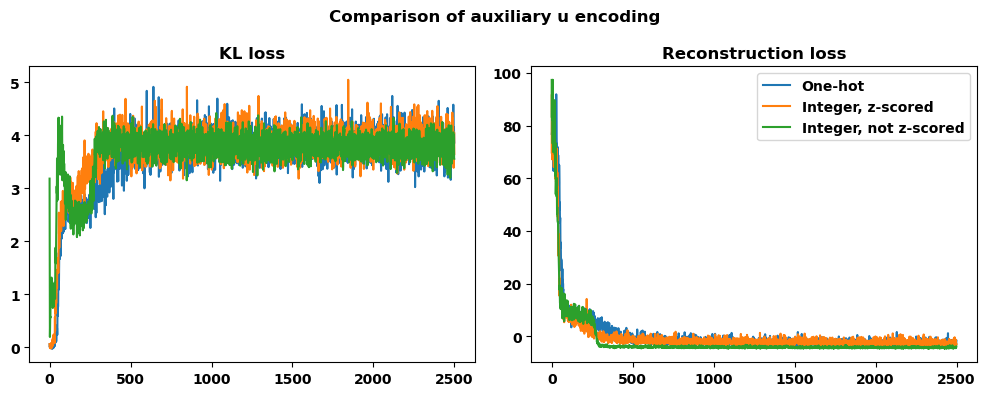

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Overall KL loss
axs[0].plot(kl_s1)
axs[0].plot(kl_s2)
axs[0].plot(kl_s3)
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon_s1, label="One-hot")
axs[1].plot(recon_s2, label="Integer, z-scored")
axs[1].plot(recon_s3, label="Integer, not z-scored")
axs[1].set_title("Reconstruction loss")
plt.legend()
plt.suptitle("Comparison of auxiliary u encoding")
plt.tight_layout()

### Latent geometry on test data

C:\Users\amand\AppData\Local\Temp\ipykernel_24220\792294884.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt_dict['cmap'] = plt.cm.get_cmap('nipy_spectral', len(lbls))


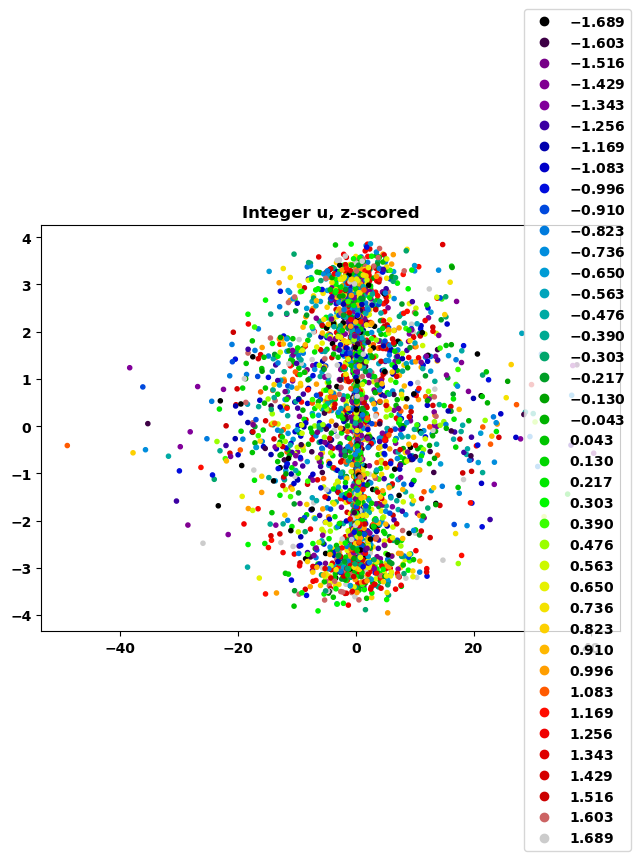

C:\Users\amand\AppData\Local\Temp\ipykernel_24220\792294884.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt_dict['cmap'] = plt.cm.get_cmap('nipy_spectral', len(lbls))


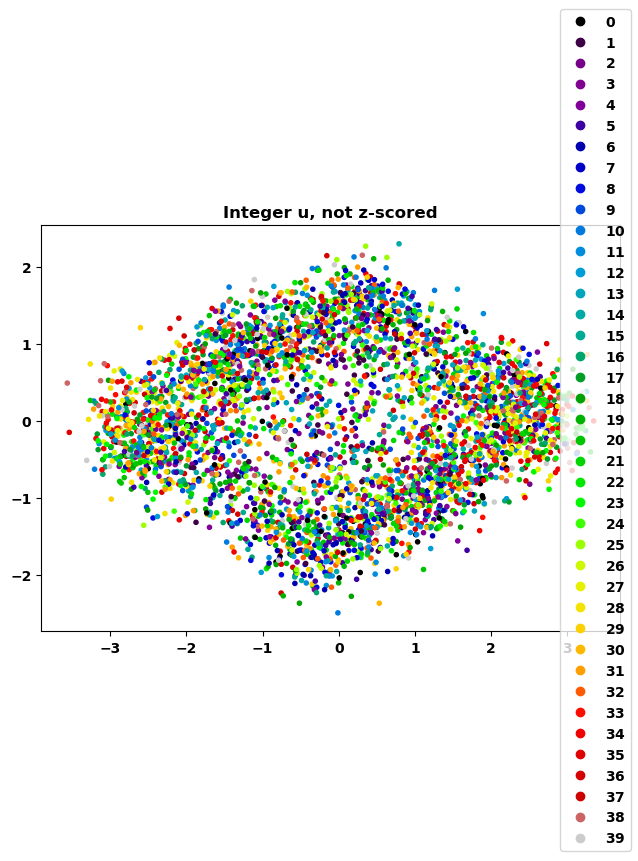

C:\Users\amand\AppData\Local\Temp\ipykernel_24220\792294884.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt_dict['cmap'] = plt.cm.get_cmap('nipy_spectral', len(lbls))


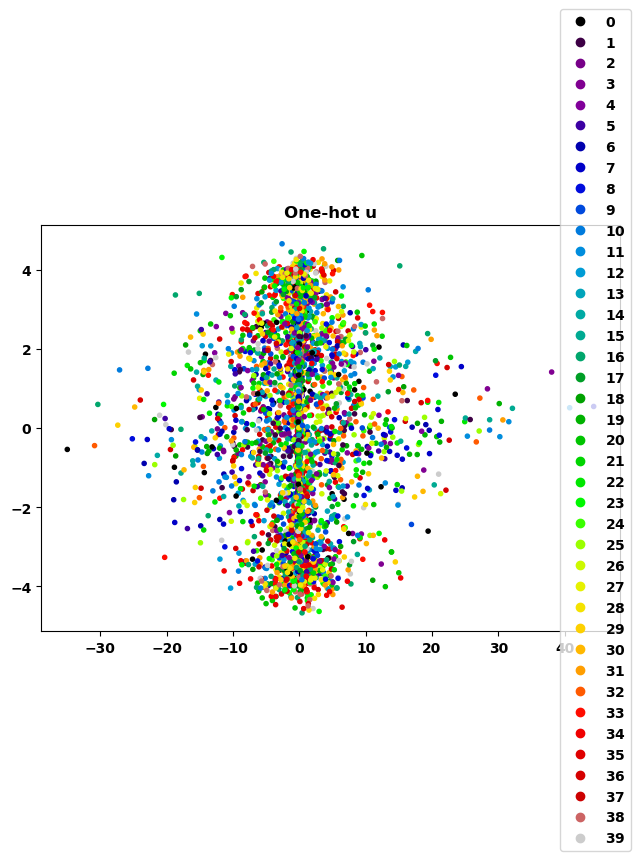

In [17]:
models = [model2, model3, model1]
test_loaders = [test_loader2, test_loader3, test_loader1]
one_hot_lst = [False, False, True]
titles = ["Integer u, z-scored", "Integer u, not z-scored", "One-hot u"]

for i in range(len(models)):
    models[i].eval()
    with torch.no_grad():
        for batch in test_loaders[i]:
            x, u = util.get_batch(batch, cfg['data_src'], device)
            if not one_hot_lst[i]:
                u = u.view(-1, 1)
            output = models[i](x, u)

            z = models[i].get_z_samples()
            u = u.detach().cpu()
            
            if i < 2:
                plot_multiple_pca([z], lbls=u, title_lst=[titles[i]])
                uval = u
            else:
                plot_multiple_pca([z], lbls=uval, title_lst=[titles[i]])

# Investigation 2: MNIST

In [18]:
# Training & model settings
cfg = {
    'rng': 1,
    'epochs': 5,
    'lr': 0.001,
    'data_src': 'MNIST',
    'batch_size': 256
}

In [19]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
valid_loader = DataLoader(valid_data, cfg['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=len(test_data))

In [20]:
# Train on MNIST
ku = 1
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
util.get_num_parameters(model)

recon_mnist, kl_mnist, metrics_mnist = util.train_ivae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 129340


100%|██████████| 5/5 [00:12<00:00,  2.49s/it]


### Plot training loss

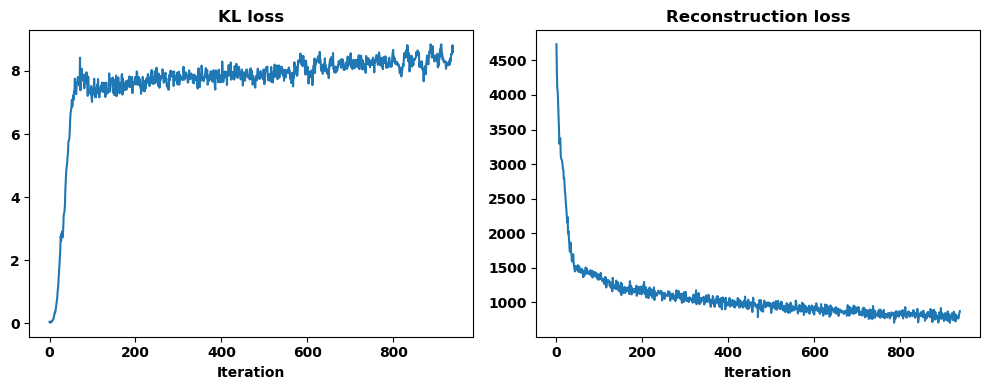

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Overall KL loss
axs[0].plot(kl_mnist)
axs[0].set_xlabel("Iteration")
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon_mnist)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

### Plot 2d PCA representation on test data

C:\Users\amand\AppData\Local\Temp\ipykernel_24220\792294884.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt_dict['cmap'] = plt.cm.get_cmap('nipy_spectral', len(lbls))


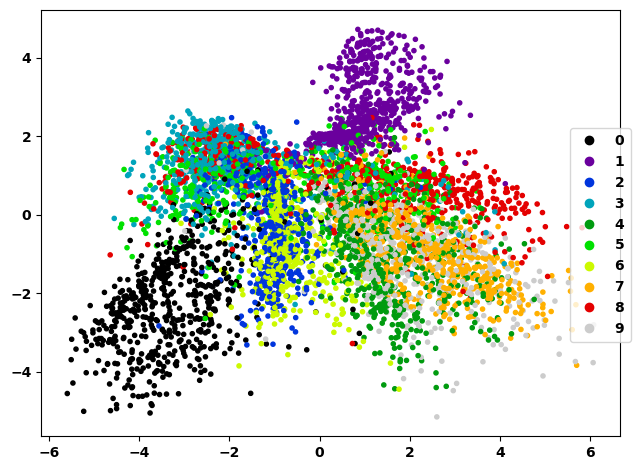

In [22]:
model.eval()
with torch.no_grad():
    for batch in test_loader:
        x, u = util.get_batch(batch, cfg['data_src'], device)
        u = u.view(-1, 1)
        output = model(x, u)

        z = model.get_z_samples()
        u = u.detach().cpu()
    
        plot_multiple_pca([z], lbls=u)